<a href="https://colab.research.google.com/github/BonneyBoja/BonneyBoja.github.io/blob/main/DATA_DRIVEN_ANALYSIS_AND_PREDICTION_OF_USED_CARS_PRICES_USING_PYTHON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Unzip the dataset file to extract the CSV.
!unzip /content/Used_Cars.zip

Archive:  /content/Used_Cars.zip
  inflating: used_cars.csv           


In [ ]:
# Import necessary libraries and load the 'used_cars.csv' dataset into a pandas DataFrame.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('used_cars.csv')

In [ ]:
# Display a concise summary of the DataFrame, including data types and non-null values.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


**Data Wrangling & Preparation**

In [ ]:
# Display the first 10 rows of the dataset to get an initial overview.
display(data.head(10))

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
5,Acura,ILX 2.4L,2016,"136,397 mi.",Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,NaN,"$14,798"
6,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,"$31,000"
7,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,"$7,300"
8,Lexus,RC 350 F Sport,2021,"23,436 mi.",Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,"$41,927"
9,Tesla,Model X Long Range Plus,2020,"34,000 mi.",NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes,"$69,950"


In [ ]:
# Clean and convert the 'milage' column to an integer type by removing commas and ' mi.'.
data['milage'] = data['milage'].str.replace(',', '').str.replace(' mi.', '', regex=False).astype(int)
display(data.head())

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [ ]:
# Define a function to extract numerical horsepower values from the 'engine' string column.
import re
import numpy as np

def extract_horsepower(engine_str):
    if isinstance(engine_str, str):
        match = re.search(r'(\d+\.?\d*)HP', engine_str)
        if match:
            return float(match.group(1))
    return np.nan

data['horsepower'] = data['engine'].apply(extract_horsepower)

# Fill NaN values with the median horsepower
median_horsepower = data['horsepower'].median()
data['horsepower'] = data['horsepower'].fillna(median_horsepower)

display(data[['engine', 'horsepower']].head(10))
print(f"Median horsepower used for filling missing values: {median_horsepower}")
print(data['horsepower'].isnull().sum())

,engine,horsepower
0,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,300.0
1,3.8L V6 24V GDI DOHC,310.0
2,3.5 Liter DOHC,310.0
3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,354.0
4,2.0L I4 16V GDI DOHC Turbo,310.0
5,2.4 Liter,310.0
6,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,292.0
7,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,282.0
8,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,311.0
9,534.0HP Electric Motor Electric Fuel System,534.0


Median horsepower used for filling missing values: 310.0
0


In [ ]:
# Create a new feature 'car_age'
data['car_age'] = 2025 - data['model_year']
display(data[['model_year', 'car_age']].head())

,model_year,car_age
0,2013,12
1,2021,4
2,2022,3
3,2015,10
4,2021,4


In [ ]:
# Clean and convert the 'price' column to a numeric data type by removing '$' and commas.
data['price'] = data['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
data['price'] = pd.to_numeric(data['price'], errors='coerce')

# Check for any remaining non-numeric values or NaNs introduced by coercion
print(f"Number of NaN values in 'price' after conversion: {data['price'].isnull().sum()}")

display(data['price'].head())

Number of NaN values in 'price' after conversion: 0


,price
0,10300
1,38005
2,54598
3,15500
4,34999


***Exploratory Data Analysis (EDA)***

**Univariate Analysis**

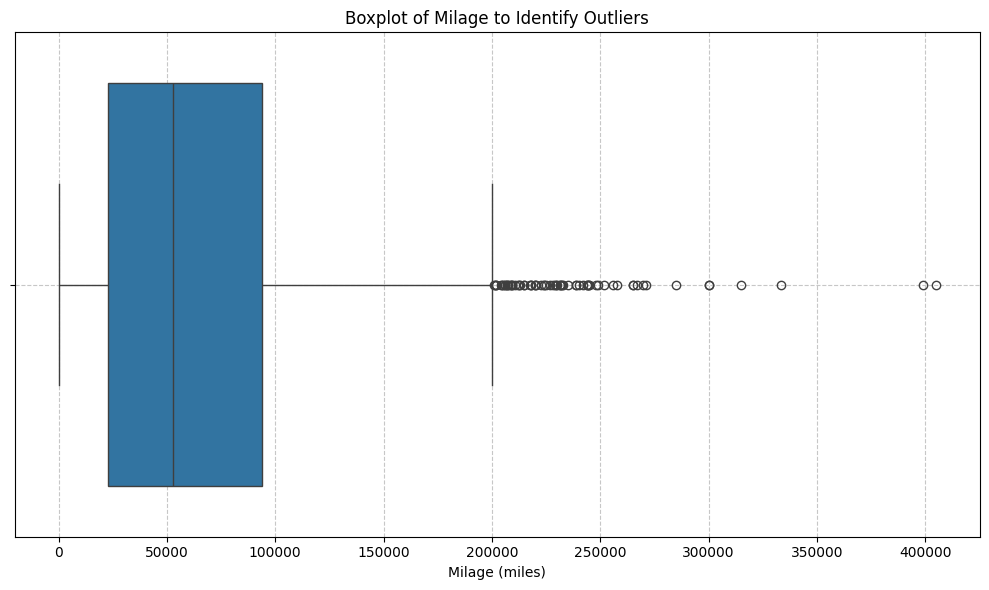

In [ ]:
# Visualize the distribution of 'milage' using a boxplot to identify outliers.
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['milage'])
plt.title('Boxplot of Milage to Identify Outliers')
plt.xlabel('Milage (miles)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

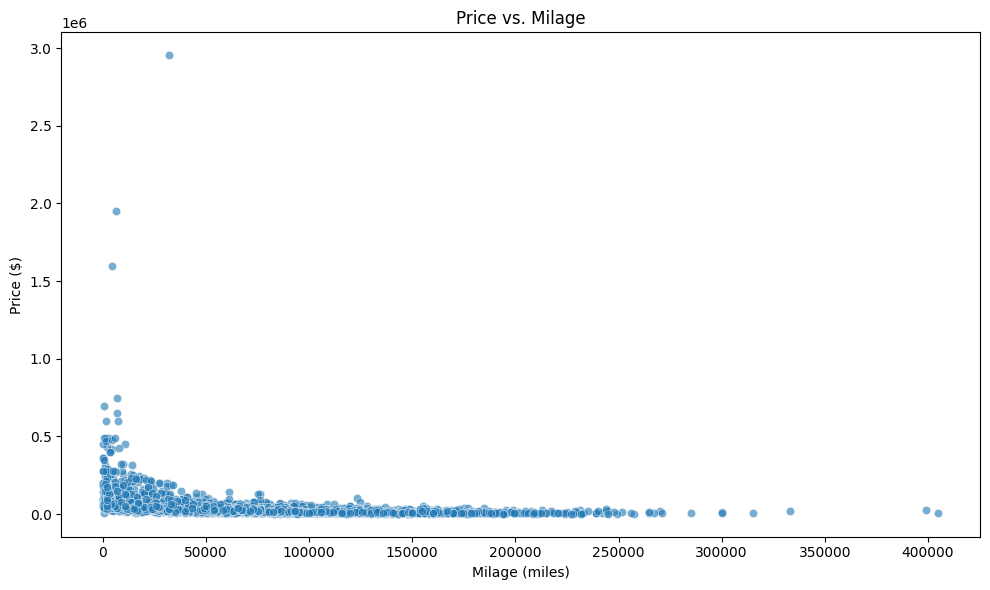

In [ ]:
# Create a scatter plot to visualize the relationship between 'milage' and 'price'.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='milage', y='price', alpha=0.6)
plt.title('Price vs. Milage')
plt.xlabel('Milage (miles)')
plt.ylabel('Price ($)')

plt.tight_layout()
plt.show()

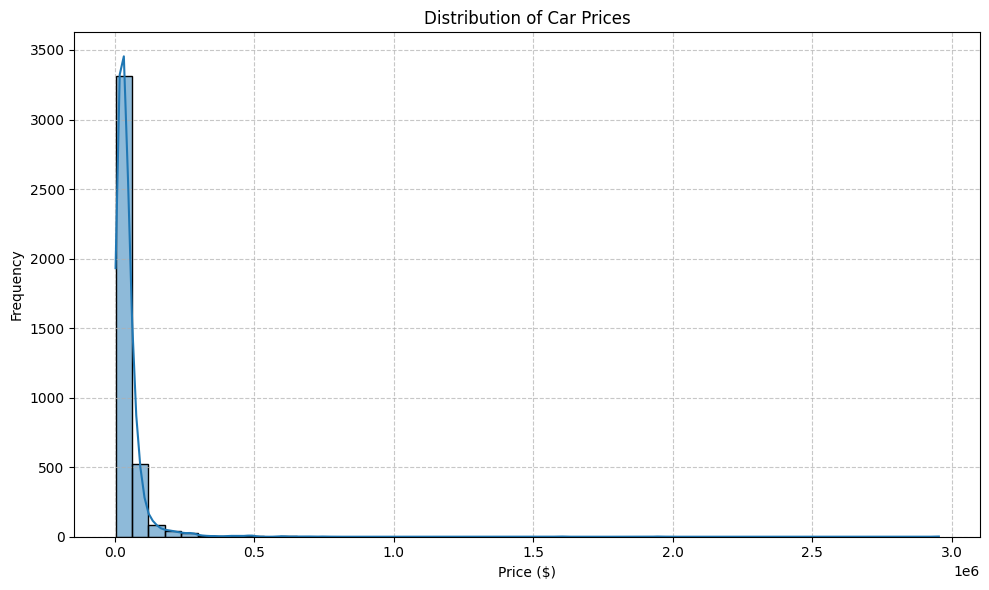

In [ ]:
# Plot a histogram to show the distribution of car 'price'.
plt.figure(figsize=(10, 6))
sns.histplot(data['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

***Bivariate Analysis***

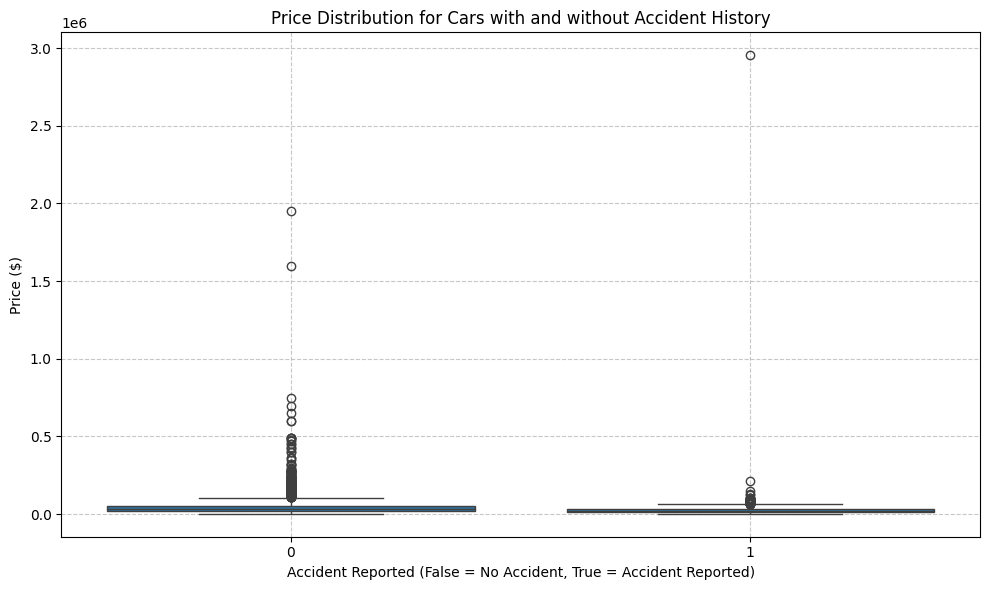

In [ ]:
# Compare the price distribution for cars with and without accident history using a boxplot.
# Create the 'accident_reported' column first
data['accident_reported'] = ((data['accident'] != 'None reported') & data['accident'].notna()).astype(int)

plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='accident_reported', y='price')
plt.title('Price Distribution for Cars with and without Accident History')
plt.xlabel('Accident Reported (False = No Accident, True = Accident Reported)')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

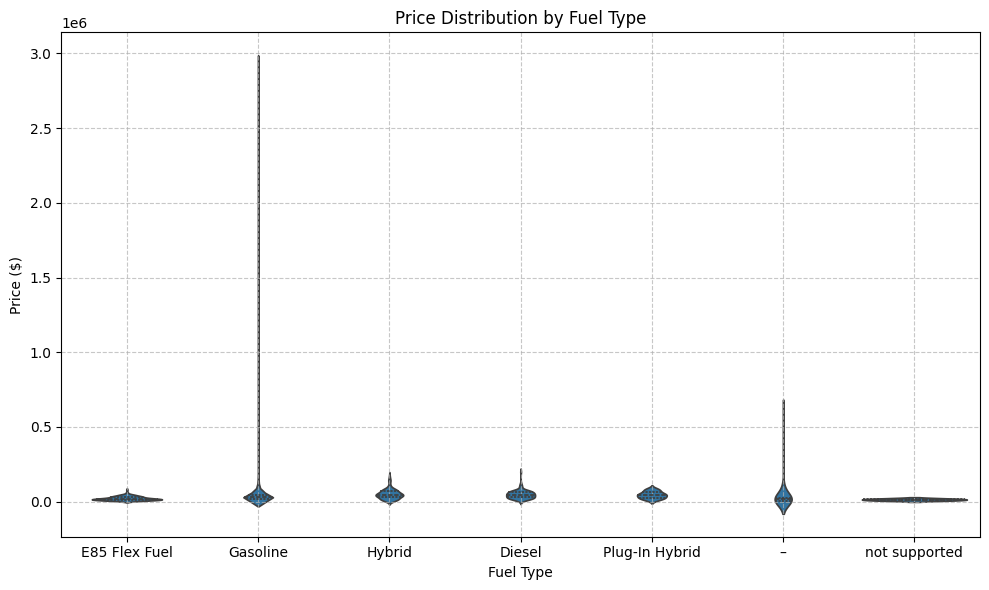

In [ ]:
# Visualize the price distribution across different 'fuel_type' categories using a violin plot.
plt.figure(figsize=(10, 6))
sns.violinplot(data=data, x='fuel_type', y='price', inner='quartile')
plt.title('Price Distribution by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Meaningful Insights from EDA
Based on the Exploratory Data Analysis we performed, here are three meaningful insights:

Inverse Relationship between Mileage and Price: The scatter plot titled 'Price vs. Milage' clearly demonstrates a negative correlation. As the mileage of a car increases, its price generally tends to decrease. This is an expected and strong trend, as higher mileage typically indicates more wear and tear, leading to depreciation.

Impact of Accident History on Price: The box plot comparing 'Price Distribution for Cars with and without Accident History' reveals a significant difference. Cars with a reported accident history (accident_reported = True) tend to have a lower median price and often a narrower, lower overall price distribution compared to vehicles without any reported accidents. This suggests that an accident history substantially reduces a car's market value.

### Data Preparation for Modeling

### Model Training and Evaluation

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_features = ['brand', 'fuel_type', 'transmission']
numerical_features = ['model_year', 'milage', 'horsepower', 'car_age', 'accident_reported', 'has_clean_title']

# Define prepocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='drop' # Change from 'passthrough' to 'drop'
)

# Create the full pipeline: preprocessing + model training
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(random_state=42, n_estimators=100))
    ]
)

print("Model pipeline defined successfully.")

Model pipeline defined successfully.


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split


# This step ensures all features used by the pipeline are present.
data['has_clean_title'] = (data['clean_title'] == 'Yes').astype(int)

# Define features (X) and target (y)
X = data.drop(columns=['price', 'model', 'ext_col', 'int_col', 'accident', 'clean_title', 'engine'])
y = np.log1p(data['price']) # Apply log transformation to the target variable for better model performance

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Train the model
model_pipeline.fit(X_train, y_train)
print("Model training complete.")

Data split into training and testing sets.
X_train shape: (3207, 9)
y_train shape: (3207,)
X_test shape: (802, 9)
y_test shape: (802,)
Model training complete.


In [ ]:
# Make predictions on the test set
y_pred_log = model_pipeline.predict(X_test)

# Inverse transform predictions and true values back to original scale for evaluation
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# Evaluate the model on the original price scale
r2 = r2_score(y_test_original, y_pred)
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)

print(f"\nModel Evaluation (on original price scale):")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Model Evaluation (on original price scale):
R-squared (R2): 0.1400
Mean Absolute Error (MAE): 17437.48
Mean Squared Error (MSE): 17577458321.96
Root Mean Squared Error (RMSE): 132580.01


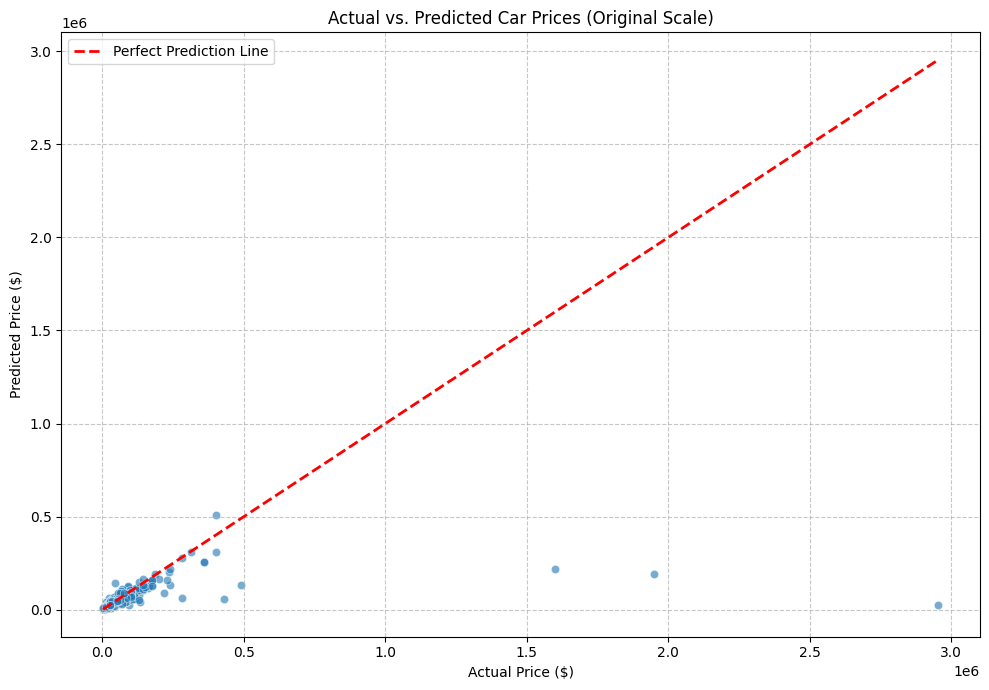

In [ ]:
# Create a scatter plot of actual vs. predicted prices
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_original, y=y_pred, alpha=0.6)
plt.plot([min(y_test_original), max(y_test_original)], [min(y_test_original), max(y_test_original)], color='red', linestyle='--', lw=2, label='Perfect Prediction Line')
plt.title('Actual vs. Predicted Car Prices (Original Scale)')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
data.to_csv('cleaned_used_cars_for_powerBi.csv', index=False)
print("\nSuccessfully exported to 'cleaned_used_cars_for_powerBi.csv'")


Successfully exported to 'cleaned_used_cars_for_powerBi.csv'


***Testing with new Data***

In [ ]:
import pandas as pd
import numpy as np
import re


test_car_input = {
    'Brand': ['BMW'],
    'Car_Age': [4],
    'Engine Size': [300.0],
    'Fuel Type': ['Petrol'],
    'Transmission': ['Automatic'],
    'Mileage': [45000],
    'Condition': ['Used']
}

required_features = ['brand', 'fuel_type', 'transmission', 'model_year', 'milage', 'horsepower', 'car_age', 'accident_reported', 'has_clean_title']
test_car_df = pd.DataFrame(columns=required_features)

# Populate test_car_df using values from test_car_input and derived features
test_car_df.loc[0, 'brand'] = test_car_input['Brand'][0]
test_car_df.loc[0, 'fuel_type'] = test_car_input['Fuel Type'][0]
test_car_df.loc[0, 'transmission'] = test_car_input['Transmission'][0]
test_car_df.loc[0, 'milage'] = test_car_input['Mileage'][0]
test_car_df.loc[0, 'car_age'] = test_car_input['Car_Age'][0]
test_car_df.loc[0, 'horsepower'] = test_car_input['Engine Size'][0]

# Derive 'model_year' from 'car_age'
test_car_df.loc[0, 'model_year'] = 2025 - test_car_df.loc[0, 'car_age']

# Add 'accident_reported' and 'has_clean_title' with default values if not provided
test_car_df.loc[0, 'accident_reported'] = 0
test_car_df.loc[0, 'has_clean_title'] = 1

# Ensure correct dtypes
test_car_df['milage'] = test_car_df['milage'].astype(int)
test_car_df['horsepower'] = test_car_df['horsepower'].astype(float)
test_car_df['car_age'] = test_car_df['car_age'].astype(int)
test_car_df['model_year'] = test_car_df['model_year'].astype(int)
test_car_df['accident_reported'] = test_car_df['accident_reported'].astype(int)
test_car_df['has_clean_title'] = test_car_df['has_clean_title'].astype(int)


# Push it through your automated pipeline
predicted_log_price = model_pipeline.predict(test_car_df)

# Reverse the Log math to get real-world dollars
predicted_real_dollars = np.expm1(predicted_log_price)[0]

for key, value in test_car_input.items():
    print(f"{key}: {value[0]}")
print(f"THE MODEL PREDICTS: ${predicted_real_dollars:,.2f}")

Brand: BMW
Car_Age: 4
Engine Size: 300.0
Fuel Type: Petrol
Transmission: Automatic
Mileage: 45000
Condition: Used
THE MODEL PREDICTS: $38,737.42


***Testing Whole DataSet***

In [ ]:
import pandas as pd

# Load the new dataset
new_cars_df = pd.read_csv('car_price_prediction_with_missing.csv')

# Display the first 5 rows to verify loading
display(new_cars_df.head())

,Car ID,brand,model_year,engine,fuel_type,transmission,milage,Condition,Price,Model,accident,clean_title,horsepower,car_age,accident_reported,has_clean_title,model,ext_col,int_col,predicted_price
0,1.0,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X,None reported,Yes,310.0,9,0,1,NaN,NaN,NaN,17413.941035
1,2.0,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series,None reported,Yes,310.0,7,0,1,NaN,NaN,NaN,26402.013504
2,3.0,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4,None reported,Yes,310.0,12,0,1,NaN,NaN,NaN,13158.028943
3,4.0,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y,None reported,Yes,310.0,14,0,1,NaN,NaN,NaN,21447.185039
4,5.0,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang,None reported,Yes,310.0,16,0,1,NaN,NaN,NaN,10545.005702


In [ ]:
import pandas as pd
import numpy as np
import re

#Helper Function
def clean_milage(milage_val):
    if isinstance(milage_val, str):
        try:
            return int(milage_val.replace(',', '').replace(' mi.', ''))
        except ValueError:
            return np.nan
    elif pd.isna(milage_val):
        return np.nan
    return milage_val
def extract_horsepower(engine_str):
    if isinstance(engine_str, str):
        match = re.search(r'(\d+\.?\d*)HP', engine_str)
        if match:
            return float(match.group(1))
    return np.nan

# Load the new dataset
new_cars_df = pd.read_csv('car_price_prediction_with_missing.csv')

# These values are derived from the original 'data' DataFrame which was processed earlier.
median_horsepower_train = data['horsepower'].median()
mode_fuel_type_train = data['fuel_type'].mode()[0]
mode_brand_train = data['brand'].mode()[0]
mode_transmission_train = data['transmission'].mode()[0]
mode_accident_train = data['accident'].mode()[0]
mode_clean_title_train = data['clean_title'].mode()[0]
median_model_year_train = data['model_year'].median()
median_milage_train = data['milage'].median()

# Rename columns to match the training data's expectations for the model pipeline
new_cars_df.rename(columns={
    'Mileage': 'milage',
    'Year': 'model_year',
    'Brand': 'brand',
    'Fuel Type': 'fuel_type',
    'Transmission': 'transmission',
    'Engine Size': 'engine',
    'Accident': 'accident',
    'Clean Title': 'clean_title',
    'Exterior Color': 'ext_col',
    'Interior Color': 'int_col'
}, inplace=True)


# Convert model_year to integer, coerce errors to NaN and then fill with median
new_cars_df['model_year'] = pd.to_numeric(new_cars_df['model_year'], errors='coerce')
new_cars_df['model_year'] = new_cars_df['model_year'].fillna(median_model_year_train).astype(int)

# Feature Engineering and Imputation
# Apply clean_milage function, then fill potential NaNs from cleaning or original data
new_cars_df['milage'] = new_cars_df['milage'].apply(clean_milage)
new_cars_df['milage'] = new_cars_df['milage'].fillna(median_milage_train).astype(int)

new_cars_df['horsepower'] = new_cars_df['engine'].apply(extract_horsepower)
new_cars_df['horsepower'] = new_cars_df['horsepower'].fillna(median_horsepower_train)

new_cars_df['car_age'] = 2025 - new_cars_df['model_year']

# Impute missing 'accident' and 'clean_title' before creating binary features
new_cars_df['accident'] = new_cars_df['accident'].fillna(mode_accident_train)
new_cars_df['clean_title'] = new_cars_df['clean_title'].fillna(mode_clean_title_train)

new_cars_df['accident_reported'] = ((new_cars_df['accident'] != 'None reported') & new_cars_df['accident'].notna()).astype(int)
new_cars_df['has_clean_title'] = (new_cars_df['clean_title'] == 'Yes').astype(int)

# Impute missing categorical features with mode from training data
new_cars_df['brand'] = new_cars_df['brand'].fillna(mode_brand_train)
new_cars_df['fuel_type'] = new_cars_df['fuel_type'].fillna(mode_fuel_type_train)
new_cars_df['transmission'] = new_cars_df['transmission'].fillna(mode_transmission_train)

# Prediction
#The model_pipeline already defined and trained from previous steps.
predicted_price_log = model_pipeline.predict(new_cars_df)
predicted_price = np.expm1(predicted_price_log)

new_cars_df['predicted_prices'] = predicted_price

display(new_cars_df.head())

output_filename = 'car_predictions_with_prices.csv'
new_cars_df.to_csv(output_filename, index=False)

,Car ID,brand,model_year,engine,fuel_type,transmission,milage,Condition,Price,Model,...,clean_title,horsepower,car_age,accident_reported,has_clean_title,model,ext_col,int_col,predicted_price,predicted_prices
0,1.0,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X,...,Yes,310.0,9,0,1,NaN,NaN,NaN,17413.941035,17413.941035
1,2.0,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series,...,Yes,310.0,7,0,1,NaN,NaN,NaN,26402.013504,26402.013504
2,3.0,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4,...,Yes,310.0,12,0,1,NaN,NaN,NaN,13158.028943,13158.028943
3,4.0,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y,...,Yes,310.0,14,0,1,NaN,NaN,NaN,21447.185039,21447.185039
4,5.0,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang,...,Yes,310.0,16,0,1,NaN,NaN,NaN,10545.005702,10545.005702


In [ ]:
#from google.colab import files

# Ensure the filename matches the one used in the previous cell
#files.download('car_predictions_with_prices.csv')

In [ ]:
import pickle

# This saves your fully trained pipeline as a file on your computer
with open('car_price_pipeline.pkl', 'wb') as file:
    pickle.dump(model_pipeline, file)

print("✅ Model successfully saved as car_price_pipeline.pkl")

✅ Model successfully saved as car_price_pipeline.pkl


In [ ]:
#from google.colab import files

#files.download('car_price_pipeline.pkl')